In [1]:
import pandas as pd
import numpy as np

# Visualisasi dasar (opsional, jangan berlebihan)
import matplotlib.pyplot as plt

# Preprocessing & modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Statistik
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier


In [2]:
# Load dataset Kaggle UMKM
df = pd.read_csv("Dataset/train/kaggle_umkm.csv")

# Cek struktur awal
df.head()


,id_umkm,nama_usaha,jenis_usaha,tenaga_kerja_perempuan,tenaga_kerja_laki_laki,aset,omset,marketplace,kapasitas_produksi,status_legalitas,tahun_berdiri,laba,biaya_karyawan,jumlah_pelanggan
0,28828567,UD. Alif Pamungkas,Kesehatan,1,56,5497149,3347794,Tokopedia,479,Belum Terdaftar,2015,-2149355,171000000,479
1,28828568,UD. Zidanar Panji,Perdagangan,5,44,7398384,39969661,Bukalapak,464,Terdaftar,2014,32571277,147000000,464
2,28828569,UD. Winda Jayengprana,unknown,74,51,8881762,25253355,Website Sendiri,383,Belum Terdaftar,2000,16371593,375000000,383
3,28828570,UD. Damaris Satria,Jasa,89,5,9576178,20700389,Website Sendiri,986,Belum Terdaftar,2003,11124211,282000000,986
4,28828571,UD. Qasya Wiratama,Jasa,91,59,9456853,4820810,Lazada,314,Belum Terdaftar,2002,-4636043,450000000,314


In [3]:
# Informasi dataset
df.info()

# Ukuran dataset
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13564 entries, 0 to 13563
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id_umkm                 13467 non-null  object
 1   nama_usaha              13564 non-null  object
 2   jenis_usaha             13467 non-null  object
 3   tenaga_kerja_perempuan  13444 non-null  object
 4   tenaga_kerja_laki_laki  13462 non-null  object
 5   aset                    13453 non-null  object
 6   omset                   13451 non-null  object
 7   marketplace             13447 non-null  object
 8   kapasitas_produksi      13442 non-null  object
 9   status_legalitas        13470 non-null  object
 10  tahun_berdiri           13469 non-null  object
 11  laba                    13452 non-null  object
 12  biaya_karyawan          13469 non-null  object
 13  jumlah_pelanggan        13453 non-null  object
dtypes: object(14)
memory usage: 1.4+ MB


(13564, 14)

In [4]:
num_cols = [
    "aset", "omset", "laba",
    "biaya_karyawan", "jumlah_pelanggan",
    "tenaga_kerja_perempuan", "tenaga_kerja_laki_laki",
    "kapasitas_produksi"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [5]:
# drop baris yang terlalu rusak
df = df.dropna(subset=["omset", "laba"])

# isi missing numerik dengan median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [6]:
median_omset = df["omset"].median()
median_laba = df["laba"].median()

df["stagnasi"] = np.where(
    (df["omset"] <= median_omset) & (df["laba"] <= median_laba),
    1, 0
)


In [7]:
df["stagnasi"].value_counts(normalize=True)


stagnasi
0    0.524046
1    0.475954
Name: proportion, dtype: float64

In [8]:
# drop kolom non-informatif JIKA ADA
cols_to_drop = ["id_umkm", "nama_usaha"]

df_model = df.drop(
    columns=[col for col in cols_to_drop if col in df.columns]
)


In [9]:
df_model.columns


Index(['jenis_usaha', 'tenaga_kerja_perempuan', 'tenaga_kerja_laki_laki',
       'aset', 'omset', 'marketplace', 'kapasitas_produksi',
       'status_legalitas', 'tahun_berdiri', 'laba', 'biaya_karyawan',
       'jumlah_pelanggan', 'stagnasi'],
      dtype='object')

In [10]:
X = df_model.drop(columns=["stagnasi"])
y = df_model["stagnasi"]


In [11]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
categorical_cols


['jenis_usaha', 'marketplace', 'status_legalitas', 'tahun_berdiri']

In [12]:
# deteksi kolom kategorikal yang MASIH ADA
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

# encoding (hanya sekali)
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

X.shape


(13266, 47)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [15]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Label distribusi:\n", y_train.value_counts(normalize=True))


Train: (10612, 47)
Test: (2654, 47)
Label distribusi:
 stagnasi
0    0.524029
1    0.475971
Name: proportion, dtype: float64


Logistic Regression


In [ ]:
logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = logreg.predict(X_test_scaled)


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

confusion_matrix(y_test, y_pred_lr)


Accuracy: 0.9913338357196684

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1391
           1       0.99      0.99      0.99      1263

    accuracy                           0.99      2654
   macro avg       0.99      0.99      0.99      2654
weighted avg       0.99      0.99      0.99      2654



array([[1381,   10],
       [  13, 1250]], dtype=int64)

XGBOOST

In [ ]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)


In [20]:
xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(X_test)


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

confusion_matrix(y_test, y_pred_xgb)


Accuracy: 0.9988696307460437

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1391
           1       1.00      1.00      1.00      1263

    accuracy                           1.00      2654
   macro avg       1.00      1.00      1.00      2654
weighted avg       1.00      1.00      1.00      2654



array([[1390,    1],
       [   2, 1261]], dtype=int64)

In [ ]:
from sklearn.metrics import f1_score

print("F1 Logistic Regression :", f1_score(y_test, y_pred_lr))
print("F1 XGBoost             :", f1_score(y_test, y_pred_xgb))


F1 Logistic Regression : 0.9908838684106223
F1 XGBoost             : 0.9988118811881188


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb)
    ]
})

results


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.991334,0.992063,0.989707,0.990884
1,XGBoost,0.998870,0.999208,0.998416,0.998812


In [27]:
results.set_index("Model").round(4)


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.9913,0.9921,0.9897,0.9909
XGBoost,0.9989,0.9992,0.9984,0.9988


<Figure size 640x480 with 0 Axes>

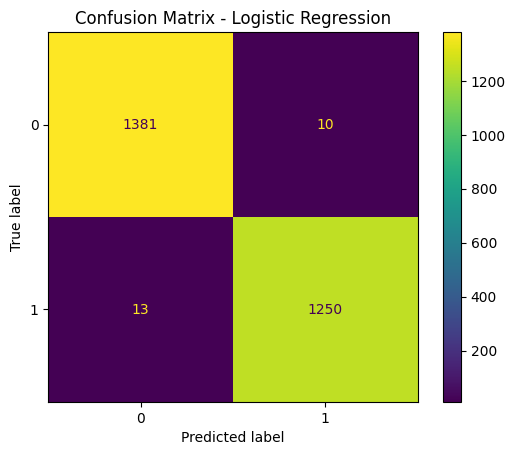

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)

plt.figure()
disp_lr.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


<Figure size 640x480 with 0 Axes>

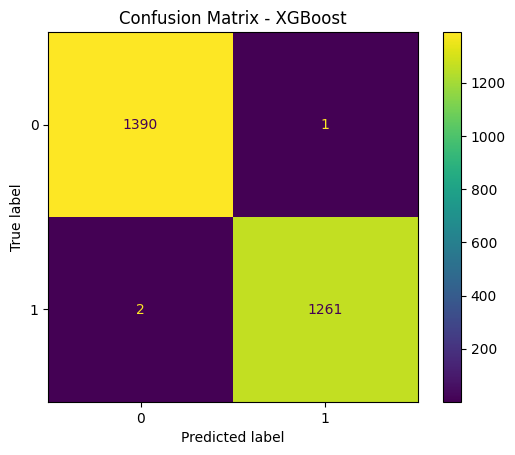

In [29]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)

plt.figure()
disp_xgb.plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()


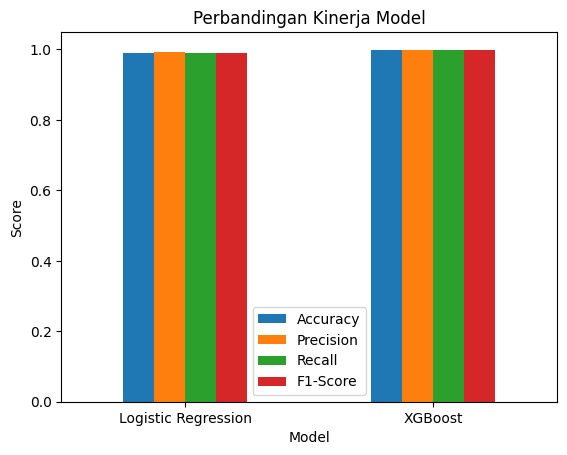

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

metrics_df = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "Accuracy": [0.9913, 0.9989],
    "Precision": [0.9921, 0.9992],
    "Recall": [0.9897, 0.9984],
    "F1-Score": [0.9909, 0.9988]
})

metrics_df.set_index("Model").plot(kind="bar")
plt.title("Perbandingan Kinerja Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()


EDA & Visualisasi Dataset Daerah

In [34]:
df_jabar = pd.read_csv("Dataset/gov_context/jawabaratkotakab_umkm.csv")
df_aceh = pd.read_csv("Dataset/gov_context/aceh_umkm.csv")


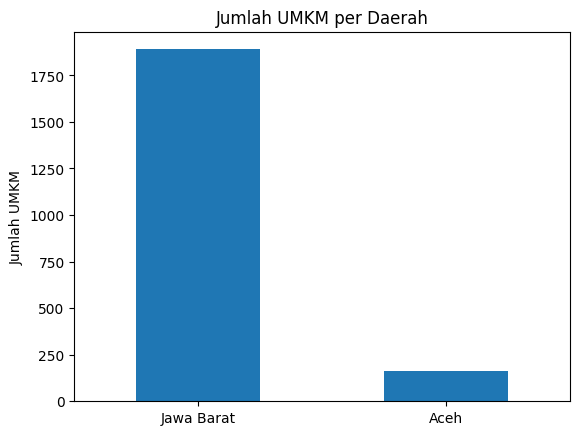

In [35]:
jumlah_umkm = {
    "Jawa Barat": len(df_jabar),
    "Aceh": len(df_aceh)
}

pd.Series(jumlah_umkm).plot(kind="bar")
plt.title("Jumlah UMKM per Daerah")
plt.ylabel("Jumlah UMKM")
plt.xticks(rotation=0)
plt.show()


In [36]:
df_jabar["jenis_usaha"].value_counts().head(10).plot(kind="bar")
plt.title("Distribusi Jenis UMKM di Jawa Barat")
plt.ylabel("Jumlah UMKM")
plt.xticks(rotation=45)
plt.show()


KeyError: 'jenis_usaha'